# EDA-06 · Khach Hang & Tang Truong (Customer & Growth)
**RFM Segmentation** · **Cohort Retention** · **Acquisition Channel Quality** · **Geographic Revenue Breakdown**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,
                     'grid.alpha':0.3,'font.size':10})

custs  = pd.read_csv('customers.csv',   parse_dates=['signup_date'])
orders = pd.read_csv('orders.csv',      parse_dates=['order_date'])
items  = pd.read_csv('order_items.csv', low_memory=False)
geo    = pd.read_csv('geography.csv')
rets   = pd.read_csv('returns.csv')

# Revenue per order line
items['rev_line'] = items['quantity'] * items['unit_price']

# Order-level revenue (all statuses, consistent with sales.csv)
order_rev = items.groupby('order_id')['rev_line'].sum().reset_index()
order_rev.columns = ['order_id', 'revenue']

# Delivered-only order revenue (for LTV quality metrics)
delivered_ids = set(orders[orders['order_status']=='delivered']['order_id'])
order_rev_del = order_rev[order_rev['order_id'].isin(delivered_ids)].copy()

# Join orders with revenue
ord_full = orders.merge(order_rev, on='order_id', how='left')
ord_del  = orders[orders['order_status']=='delivered'].merge(order_rev_del, on='order_id', how='left')

# Return flag per order
ret_orders = set(rets['order_id'].unique())

# Geography lookup: zip -> region
zip_region = geo.drop_duplicates('zip')[['zip','region']]
custs_geo  = custs.merge(zip_region, on='zip', how='left')

REF_DATE = orders['order_date'].max()
print(f'Reference date  : {REF_DATE.date()}')
print(f'Customers       : {len(custs):,}')
print(f'Orders          : {len(orders):,}  (delivered: {len(ord_del):,})')
print(f'acquisition_channel unique: {custs["acquisition_channel"].unique().tolist()}')
print(f'Regions         : {geo["region"].unique().tolist()}')


Reference date  : 2022-12-31
Customers       : 121,930
Orders          : 646,945  (delivered: 516,716)
acquisition_channel unique: ['social_media', 'email_campaign', 'organic_search', 'referral', 'direct', 'paid_search']
Regions         : ['East', 'Central', 'West']


## Part 1 · RFM Segmentation
Scoring quintile 1-5 (5=tot nhat). Segment dua tren to hop R+F+M score.

In [2]:
# RFM trên toàn bộ status (consistent với revenue target)
cust_orders = ord_full.groupby('customer_id').agg(
    last_order   = ('order_date', 'max'),
    frequency    = ('order_id',   'count'),
    monetary     = ('revenue',    'sum'),
).reset_index()

cust_orders['recency_days'] = (REF_DATE - cust_orders['last_order']).dt.days

# Quintile scoring (5=best)
cust_orders['R'] = pd.qcut(cust_orders['recency_days'], 5, labels=[5,4,3,2,1]).astype(int)
cust_orders['F'] = pd.qcut(cust_orders['frequency'].rank(method='first'), 5,
                            labels=[1,2,3,4,5]).astype(int)
cust_orders['M'] = pd.qcut(cust_orders['monetary'].rank(method='first'), 5,
                            labels=[1,2,3,4,5]).astype(int)
cust_orders['RFM_score'] = cust_orders['R'] + cust_orders['F'] + cust_orders['M']

# Segment mapping
def rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    score = r + f + m
    if r >= 4 and f >= 4 and m >= 4:  return 'Champions'
    if r >= 3 and f >= 3 and m >= 3:  return 'Loyalists'
    if r >= 4 and f <= 2:             return 'New / Promising'
    if r <= 2 and f >= 4:             return 'At Risk'
    if score >= 9:                    return 'Loyalists'
    if score >= 6:                    return 'Potential'
    if r <= 2 and score <= 5:         return 'Lost'
    return 'Hibernating'

cust_orders['segment'] = cust_orders.apply(rfm_segment, axis=1)

seg_order = ['Champions','Loyalists','Potential','New / Promising','Hibernating','At Risk','Lost']
seg_summary = cust_orders.groupby('segment').agg(
    n_customers  = ('customer_id',   'count'),
    avg_recency  = ('recency_days',  'mean'),
    avg_freq     = ('frequency',     'mean'),
    avg_monetary = ('monetary',      'mean'),
    total_rev    = ('monetary',      'sum'),
).reset_index()
seg_summary['rev_share_pct'] = seg_summary['total_rev'] / seg_summary['total_rev'].sum() * 100
seg_summary['cust_share_pct'] = seg_summary['n_customers'] / seg_summary['n_customers'].sum() * 100
present_segs = seg_summary['segment'].tolist()
seg_summary = seg_summary.set_index('segment').reindex(
    [s for s in seg_order if s in present_segs]).reset_index()

print('=== RFM Segment Summary ===')
print(seg_summary[['segment','n_customers','cust_share_pct','avg_freq',
                    'avg_monetary','rev_share_pct']].to_string(index=False))
print()
print(f'RFM score range: {cust_orders["RFM_score"].min()} - {cust_orders["RFM_score"].max()}')


=== RFM Segment Summary ===
        segment  n_customers  cust_share_pct  avg_freq  avg_monetary  rev_share_pct
      Champions        23446       25.980099 17.157511 447631.996880      63.876296
      Loyalists        19718       21.849168  7.001369 176829.776439      21.221110
      Potential        16968       18.801941  2.645863  63966.919966       6.605960
New / Promising         4869        5.395253  1.614705  46884.596118       1.389376
    Hibernating         1236        1.369590  1.000000  11180.008746       0.084103
        At Risk         3247        3.597943  8.426856 200056.099116       3.953520
           Lost        20762       23.006006  1.216742  22709.508415       2.869636

RFM score range: 3 - 15


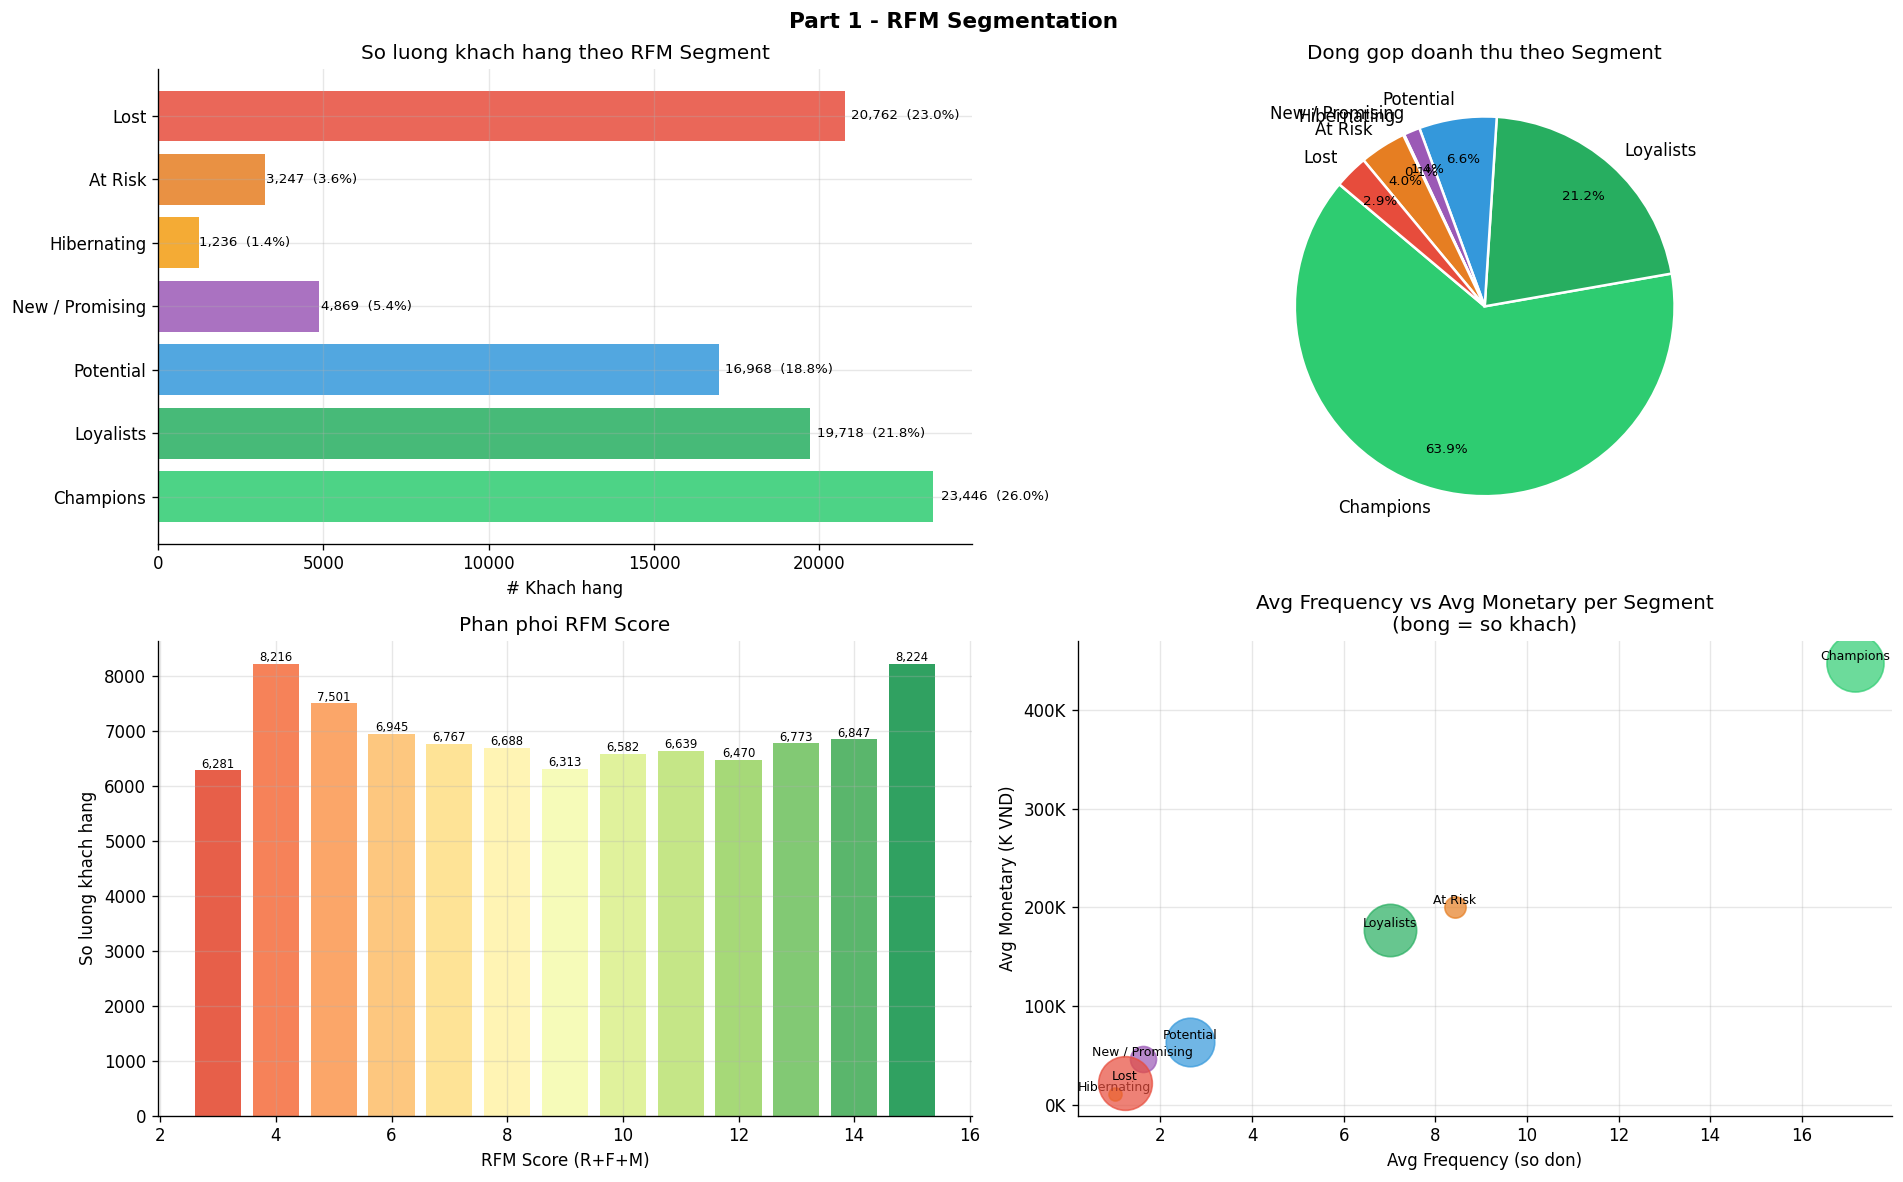

In [3]:
SEG_COLORS = {
    'Champions':      '#2ecc71',
    'Loyalists':      '#27ae60',
    'Potential':      '#3498db',
    'New / Promising':'#9b59b6',
    'Hibernating':    '#f39c12',
    'At Risk':        '#e67e22',
    'Lost':           '#e74c3c',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
seg_plot = seg_summary.dropna(subset=['segment'])
colors_  = [SEG_COLORS.get(s, '#aaa') for s in seg_plot['segment']]

# ── A: Customer count per segment ────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(seg_plot['segment'], seg_plot['n_customers'], color=colors_, alpha=0.85)
ax.set_xlabel('# Khach hang')
ax.set_title('So luong khach hang theo RFM Segment')
for bar, row in zip(bars, seg_plot.itertuples()):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{row.n_customers:,}  ({row.cust_share_pct:.1f}%)',
            va='center', fontsize=8)

# ── B: Revenue contribution ───────────────────────────────────────────────────
ax = axes[1]
wedges, _, autotexts = ax.pie(
    seg_plot['total_rev'], labels=seg_plot['segment'],
    autopct='%1.1f%%', colors=colors_, startangle=140,
    pctdistance=0.78, wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts: at.set_fontsize(8)
ax.set_title('Dong gop doanh thu theo Segment')

# ── C: RFM score distribution ─────────────────────────────────────────────────
ax = axes[2]
score_dist = cust_orders['RFM_score'].value_counts().sort_index()
bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(score_dist)))
ax.bar(score_dist.index, score_dist.values, color=bar_colors, alpha=0.9)
ax.set_xlabel('RFM Score (R+F+M)')
ax.set_ylabel('So luong khach hang')
ax.set_title('Phan phoi RFM Score')
for x, y in zip(score_dist.index, score_dist.values):
    ax.text(x, y+50, f'{y:,}', ha='center', fontsize=7)

# ── D: Avg Monetary vs Avg Frequency per segment (bubble = n_customers) ───────
ax = axes[3]
for _, row in seg_plot.iterrows():
    ax.scatter(row['avg_freq'], row['avg_monetary']/1e3,
               s=row['n_customers']/20, alpha=0.7,
               color=SEG_COLORS.get(row['segment'],'#aaa'),
               label=row['segment'], zorder=3)
    ax.annotate(row['segment'], (row['avg_freq'], row['avg_monetary']/1e3),
                fontsize=7.5, ha='center', va='bottom')
ax.set_xlabel('Avg Frequency (so don)')
ax.set_ylabel('Avg Monetary (K VND)')
ax.set_title('Avg Frequency vs Avg Monetary per Segment\n(bong = so khach)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}K'))

plt.suptitle('Part 1 - RFM Segmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cust_p1_rfm.png', bbox_inches='tight')
plt.show()


## Part 2 · Cohort Retention
> **Luu y:** 73.8% khach hang co `signup_date > order_date` (da mua hang truoc khi chinh thuc dang ky). Do do notebook nay tinh **2 cohort song song**: (1) First-order cohort — chinh xac hon ve hanh vi; (2) Signup-date cohort — theo yeu cau, chi tinh retention voi don hang SAU khi dang ky.

In [4]:
# Luu y: 73.8% khach hang co signup_date > order_date (da mua truoc khi dang ky)
# -> Dung first_order_date lam cohort chinh xac hon; so sanh voi signup cohort

# ── Cohort 1: dua tren thang dau tien mua hang ───────────────────────────────
first_order = (ord_full.groupby('customer_id')['order_date']
               .min().reset_index().rename(columns={'order_date':'first_order_date'}))
ord_cohort = ord_full.merge(first_order, on='customer_id', how='left')
ord_cohort['cohort_year']     = ord_cohort['first_order_date'].dt.year
ord_cohort['order_year']      = ord_cohort['order_date'].dt.year
ord_cohort['period_offset']   = (ord_cohort['order_year'] - ord_cohort['cohort_year'])

# Annual cohort retention (year-level to keep matrix readable)
cohort_size = (ord_cohort.groupby('cohort_year')['customer_id']
               .nunique().reset_index().rename(columns={'customer_id':'cohort_size'}))

cohort_ret = (ord_cohort.groupby(['cohort_year','period_offset'])['customer_id']
              .nunique().reset_index().rename(columns={'customer_id':'n_active'}))
cohort_ret = cohort_ret.merge(cohort_size, on='cohort_year', how='left')
cohort_ret['retention_pct'] = cohort_ret['n_active'] / cohort_ret['cohort_size'] * 100

retention_matrix = cohort_ret.pivot(index='cohort_year',
                                     columns='period_offset',
                                     values='retention_pct')
# Limit to offsets 0-8
cols_show = [c for c in range(9) if c in retention_matrix.columns]
retention_matrix = retention_matrix[cols_show]

# ── Cohort 2: dua tren signup_date (theo yeu cau) ────────────────────────────
custs_yr = custs.copy()
custs_yr['signup_year'] = custs_yr['signup_date'].dt.year

ord_signup = ord_full.merge(custs_yr[['customer_id','signup_year']], on='customer_id', how='left')
ord_signup['order_year']    = ord_signup['order_date'].dt.year
ord_signup['period_offset'] = ord_signup['order_year'] - ord_signup['signup_year']

# Chi giu offset >= 0 (mua sau khi dang ky) va offset 0..6
ord_signup_pos = ord_signup[ord_signup['period_offset'] >= 0]
signup_cohort_size = (custs_yr.groupby('signup_year')['customer_id']
                     .count().reset_index().rename(columns={'customer_id':'cohort_size'}))

signup_ret = (ord_signup_pos.groupby(['signup_year','period_offset'])['customer_id']
              .nunique().reset_index().rename(columns={'customer_id':'n_active'}))
signup_ret = signup_ret.merge(signup_cohort_size, on='signup_year', how='left')
signup_ret['retention_pct'] = signup_ret['n_active'] / signup_ret['cohort_size'] * 100

signup_matrix = signup_ret.pivot(index='signup_year',
                                  columns='period_offset',
                                  values='retention_pct')
cols_s = [c for c in range(7) if c in signup_matrix.columns]
signup_matrix = signup_matrix[cols_s]

print('=== Cohort Retention Matrix (First-Order Cohort) ===')
print(retention_matrix.round(1).to_string())
print()
print('=== Cohort Retention Matrix (Signup Cohort, offset>=0) ===')
print(signup_matrix.round(1).to_string())


=== Cohort Retention Matrix (First-Order Cohort) ===
period_offset      0     1     2     3     4     5     6     7     8
cohort_year                                                         
2012           100.0  64.7  65.0  65.6  65.9  63.9  61.9  47.6  43.0
2013           100.0  50.8  51.1  50.9  49.5  47.4  35.0  31.2  30.7
2014           100.0  35.1  36.0  34.1  32.5  22.4  19.9  19.2  20.2
2015           100.0  27.4  27.7  25.5  16.4  14.2  14.6  14.8   NaN
2016           100.0  21.2  20.4  12.6  11.4  10.7  11.1   NaN   NaN
2017           100.0  16.1  11.7   9.3   9.7   8.7   NaN   NaN   NaN
2018           100.0   9.4   8.3   8.1   8.4   NaN   NaN   NaN   NaN
2019           100.0   7.6   7.2   7.3   NaN   NaN   NaN   NaN   NaN
2020           100.0   6.8   7.1   NaN   NaN   NaN   NaN   NaN   NaN
2021           100.0   6.7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2022           100.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN

=== Cohort Retention Matrix (Signup Cohort, offse

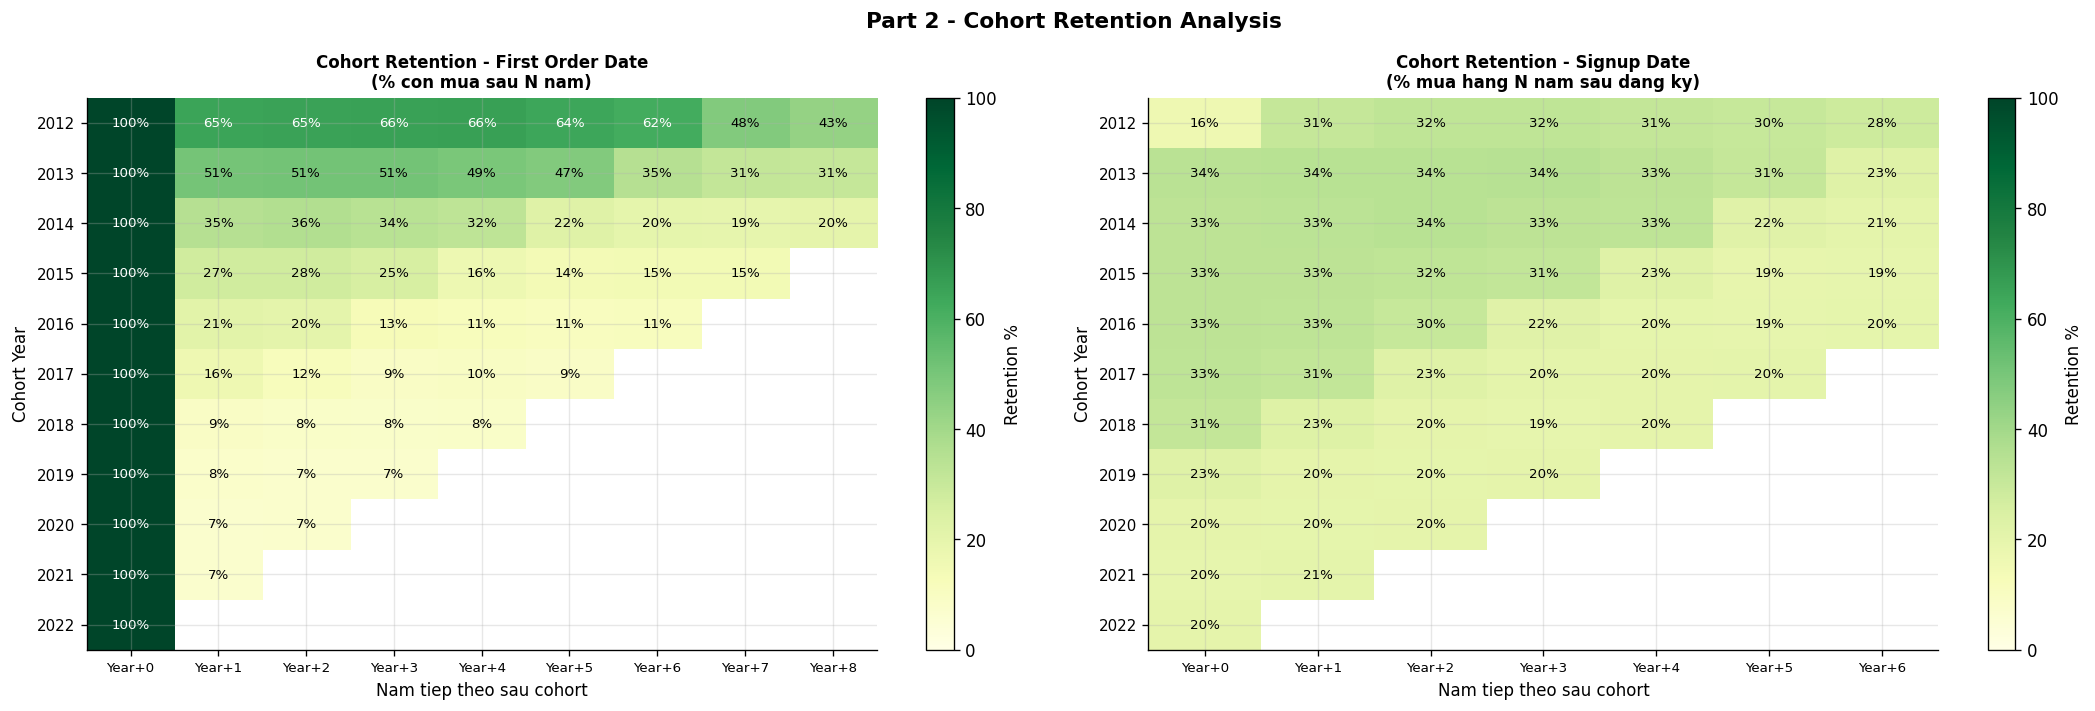

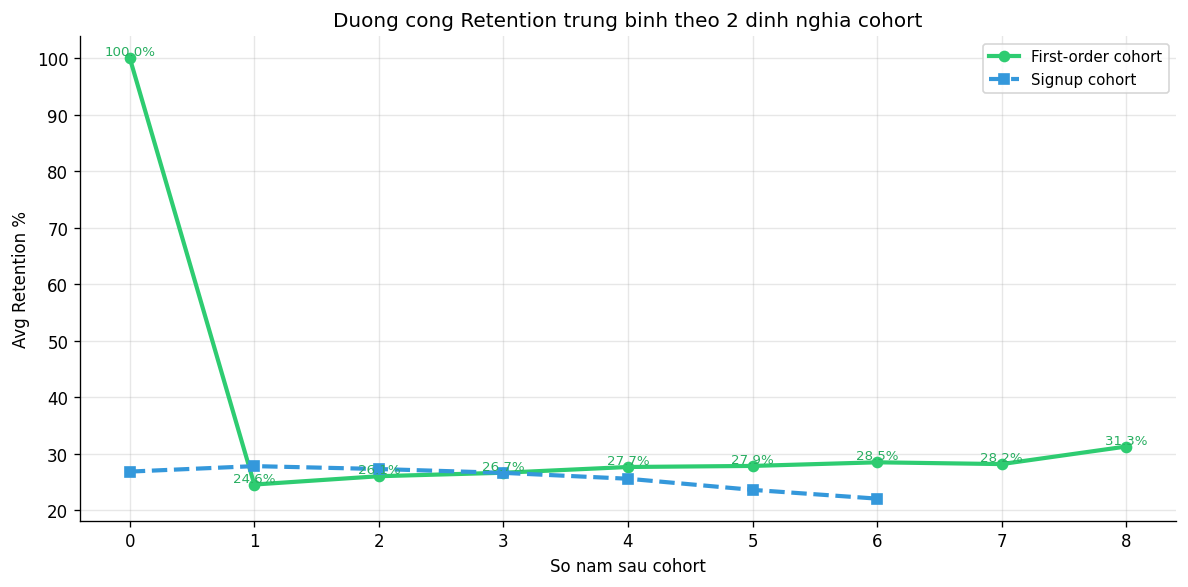

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

def draw_heatmap(ax, matrix, title):
    import matplotlib.colors as mcolors
    data = matrix.values
    im   = ax.imshow(data, cmap='YlGn', aspect='auto', vmin=0, vmax=100)
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels([f'Year+{c}' for c in matrix.columns], fontsize=8)
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels(matrix.index.astype(int), fontsize=9)
    ax.set_xlabel('Nam tiep theo sau cohort')
    ax.set_ylabel('Cohort Year')
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Retention %')
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=8,
                        color='white' if val > 60 else 'black')

draw_heatmap(axes[0], retention_matrix,
             'Cohort Retention - First Order Date\n(% con mua sau N nam)')
draw_heatmap(axes[1], signup_matrix,
             'Cohort Retention - Signup Date\n(% mua hang N nam sau dang ky)')

plt.suptitle('Part 2 - Cohort Retention Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cust_p2_cohort.png', bbox_inches='tight')
plt.show()

# ── Avg retention curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
avg_ret = retention_matrix.mean(axis=0)
ax.plot(avg_ret.index, avg_ret.values, marker='o', lw=2.5, color='#2ecc71', label='First-order cohort')
avg_ret_s = signup_matrix.mean(axis=0)
ax.plot(avg_ret_s.index, avg_ret_s.values, marker='s', lw=2.5, color='#3498db',
        linestyle='--', label='Signup cohort')
ax.set_xlabel('So nam sau cohort'); ax.set_ylabel('Avg Retention %')
ax.set_title('Duong cong Retention trung binh theo 2 dinh nghia cohort')
ax.legend(fontsize=9)
for x, y in zip(avg_ret.index, avg_ret.values):
    ax.text(x, y+0.5, f'{y:.1f}%', ha='center', fontsize=8, color='#27ae60')
plt.tight_layout()
plt.savefig('fig_cust_p2_curve.png', bbox_inches='tight')
plt.show()


## Part 3 · Acquisition Channel Quality
Metrics: LTV, avg orders, one-time buyer %, return rate, revenue trong 90 ngay dau, quality score tong hop.

In [6]:
# Join customers -> orders -> revenue
cust_ord = custs_geo.merge(
    ord_full[['order_id','customer_id','order_date','order_status','revenue']],
    on='customer_id', how='left'
)
cust_ord['returned_order'] = cust_ord['order_id'].isin(ret_orders)

# LTV metrics per customer
cust_ltv = cust_ord.groupby(['customer_id','acquisition_channel','region']).agg(
    n_orders      = ('order_id',        'nunique'),
    total_rev     = ('revenue',         'sum'),
    n_returned    = ('returned_order',  'sum'),
    first_order   = ('order_date',      'min'),
    last_order    = ('order_date',      'max'),
).reset_index()
cust_ltv['return_rate']     = cust_ltv['n_returned'] / cust_ltv['n_orders']
cust_ltv['avg_order_value'] = cust_ltv['total_rev']  / cust_ltv['n_orders']
cust_ltv['is_one_time']     = cust_ltv['n_orders'] == 1
cust_ltv['active_days']     = (cust_ltv['last_order'] - cust_ltv['first_order']).dt.days

# Channel-level summary
channel_summary = cust_ltv.groupby('acquisition_channel').agg(
    n_customers     = ('customer_id',    'count'),
    avg_ltv         = ('total_rev',      'mean'),
    median_ltv      = ('total_rev',      'median'),
    avg_orders      = ('n_orders',       'mean'),
    pct_one_time    = ('is_one_time',    'mean'),
    avg_return_rate = ('return_rate',    'mean'),
    total_rev       = ('total_rev',      'sum'),
    avg_active_days = ('active_days',    'mean'),
).reset_index()
channel_summary['pct_one_time']    *= 100
channel_summary['avg_return_rate'] *= 100
channel_summary['rev_share_pct']    = (channel_summary['total_rev'] /
                                        channel_summary['total_rev'].sum() * 100)
channel_summary = channel_summary.sort_values('avg_ltv', ascending=False)

print('=== Acquisition Channel Quality ===')
cols = ['acquisition_channel','n_customers','avg_ltv','avg_orders',
        'pct_one_time','avg_return_rate','avg_active_days','rev_share_pct']
print(channel_summary[cols].to_string(index=False))
print()

# Early value: revenue trong 90 ngay dau sau first_order
cust_ltv2 = cust_ord.copy()
cust_ltv2 = cust_ltv2.merge(
    cust_ord.groupby('customer_id')['order_date'].min().rename('first_ord'),
    on='customer_id', how='left'
)
cust_ltv2['days_since_first'] = (cust_ltv2['order_date'] - cust_ltv2['first_ord']).dt.days
early = cust_ltv2[cust_ltv2['days_since_first'] <= 90]
early_rev = early.groupby(['customer_id','acquisition_channel'])['revenue'].sum().reset_index()
early_rev.columns = ['customer_id','acquisition_channel','rev_90d']
early_channel = (early_rev.groupby('acquisition_channel')['rev_90d']
                 .mean().reset_index().rename(columns={'rev_90d':'avg_rev_90d'}))
channel_summary = channel_summary.merge(early_channel, on='acquisition_channel', how='left')
print('avg_rev_90d (doanh thu TB trong 90 ngay dau) theo channel:')
print(channel_summary[['acquisition_channel','avg_rev_90d','avg_ltv']].to_string(index=False))

# Channel quality score: min-max normalize thu cong
score_df = channel_summary.set_index('acquisition_channel')[
    ['avg_ltv','avg_orders','avg_active_days']].copy()
score_df['pct_one_time_inv'] = 100 - channel_summary.set_index('acquisition_channel')['pct_one_time']
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0 + 0.5
score_norm = score_df.apply(minmax)
score_norm['quality_score'] = score_norm.mean(axis=1) * 100
channel_summary = channel_summary.merge(
    score_norm[['quality_score']].reset_index(), on='acquisition_channel', how='left')
channel_summary = channel_summary.sort_values('quality_score', ascending=False)
print()
print('=== Channel Quality Score (0-100) ===')
print(channel_summary[['acquisition_channel','quality_score','avg_ltv',
                        'avg_orders','pct_one_time','avg_return_rate']].to_string(index=False))


=== Acquisition Channel Quality ===
acquisition_channel  n_customers       avg_ltv  avg_orders  pct_one_time  avg_return_rate  avg_active_days  rev_share_pct
     organic_search        36450 135461.504844    5.328587     18.200274         5.610489      1764.946679      30.051300
       social_media        24448 135314.594998    5.296875     17.911486         5.471847      1777.578936      20.134359
        paid_search        24285 134721.950097    5.309986     18.513486         5.560454      1759.397633      19.912524
     email_campaign        14674 134054.179683    5.300191     18.720185         5.954127      1748.483741      11.972331
             direct         9803 133727.478648    5.306437     18.830970         5.684758      1747.331471       7.978652
           referral        12270 133249.344049    5.254523     18.386308         5.589665      1752.889330       9.950834

avg_rev_90d (doanh thu TB trong 90 ngay dau) theo channel:
acquisition_channel  avg_rev_90d       avg_ltv
   

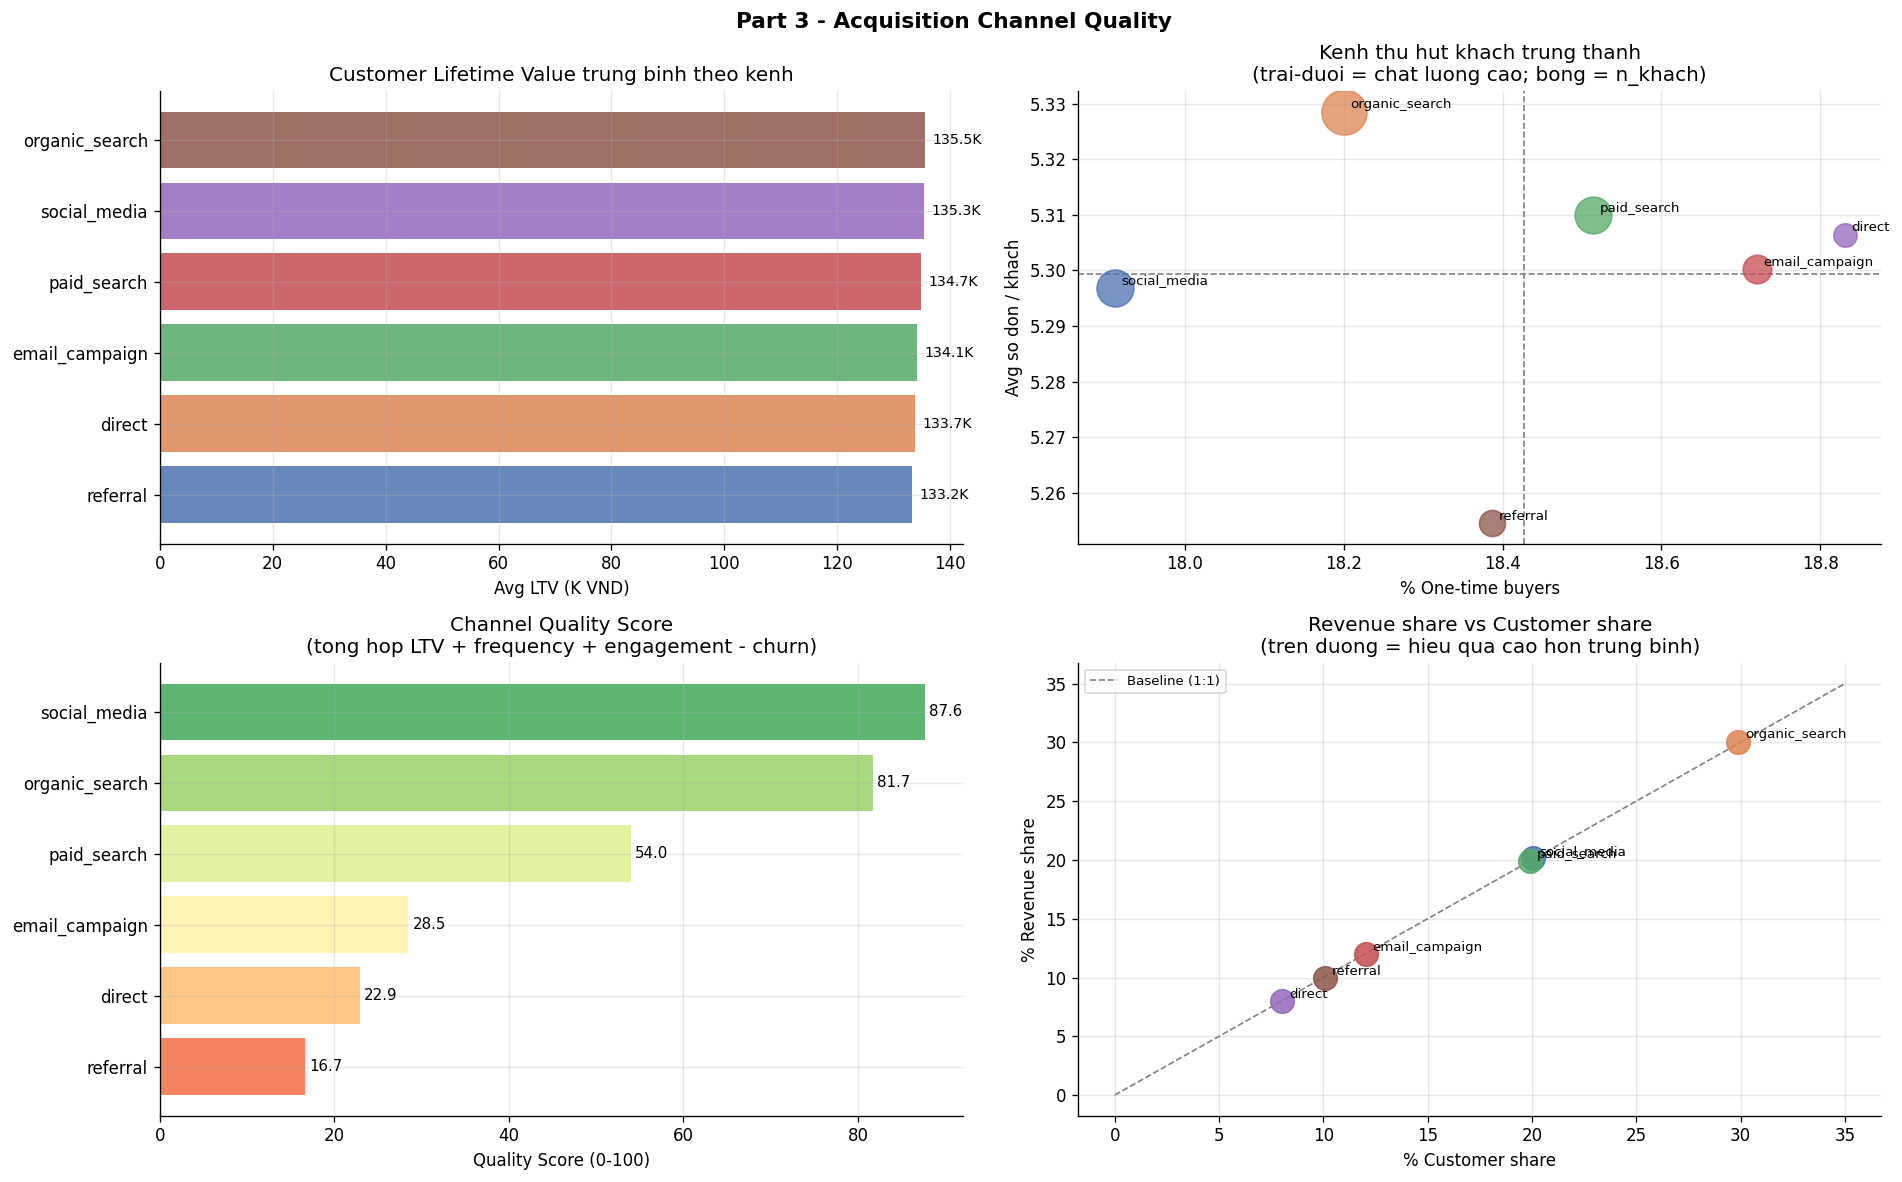

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
CH_COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#9467BD','#8C564B']
ch_sorted = channel_summary.sort_values('avg_ltv', ascending=True)

# ── A: Avg LTV per channel ────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(ch_sorted['acquisition_channel'], ch_sorted['avg_ltv']/1e3,
               color=CH_COLORS[:len(ch_sorted)], alpha=0.85)
ax.set_xlabel('Avg LTV (K VND)')
ax.set_title('Customer Lifetime Value trung binh theo kenh')
for bar, val in zip(bars, ch_sorted['avg_ltv']):
    ax.text(val/1e3*1.01, bar.get_y()+bar.get_height()/2,
            f'{val/1e3:.1f}K', va='center', fontsize=8.5)

# ── B: One-time buyer % vs Avg orders ────────────────────────────────────────
ax = axes[1]
for i, row in channel_summary.iterrows():
    ax.scatter(row['pct_one_time'], row['avg_orders'],
               s=row['n_customers']/50, alpha=0.75,
               color=CH_COLORS[list(channel_summary.index).index(i) % len(CH_COLORS)],
               zorder=3)
    ax.annotate(row['acquisition_channel'], (row['pct_one_time'], row['avg_orders']),
                fontsize=8, xytext=(4,2), textcoords='offset points')
ax.set_xlabel('% One-time buyers')
ax.set_ylabel('Avg so don / khach')
ax.set_title('Kenh thu hut khach trung thanh\n(trai-duoi = chat luong cao; bong = n_khach)')
ax.axvline(channel_summary['pct_one_time'].mean(), color='grey', lw=1, linestyle='--')
ax.axhline(channel_summary['avg_orders'].mean(),   color='grey', lw=1, linestyle='--')

# ── C: Channel quality score radar / bar ─────────────────────────────────────
ax = axes[2]
cq = channel_summary.sort_values('quality_score', ascending=True)
colors_q = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(cq)))
bars2 = ax.barh(cq['acquisition_channel'], cq['quality_score'],
                color=colors_q, alpha=0.85)
ax.set_xlabel('Quality Score (0-100)')
ax.set_title('Channel Quality Score\n(tong hop LTV + frequency + engagement - churn)')
for bar, val in zip(bars2, cq['quality_score']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

# ── D: Revenue share vs customer share (efficiency) ──────────────────────────
ax = axes[3]
for i, (_, row) in enumerate(channel_summary.iterrows()):
    ax.scatter(row['n_customers']/channel_summary['n_customers'].sum()*100,
               row['rev_share_pct'],
               s=200, alpha=0.85, color=CH_COLORS[i % len(CH_COLORS)], zorder=3)
    ax.annotate(row['acquisition_channel'],
                (row['n_customers']/channel_summary['n_customers'].sum()*100,
                 row['rev_share_pct']),
                fontsize=8, xytext=(4,2), textcoords='offset points')
# Duong chia doi: neu revenue_share = customer_share -> hieu qua trung binh
lim = max(channel_summary['n_customers'].sum(), 1)
ax.plot([0,35],[0,35], color='grey', lw=1, linestyle='--', label='Baseline (1:1)')
ax.set_xlabel('% Customer share')
ax.set_ylabel('% Revenue share')
ax.set_title('Revenue share vs Customer share\n(tren duong = hieu qua cao hon trung binh)')
ax.legend(fontsize=8)

plt.suptitle('Part 3 - Acquisition Channel Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cust_p3_channel.png', bbox_inches='tight')
plt.show()


## Part 4 · Geographic Revenue Breakdown

In [8]:
# cust_ord da co 'region' tu custs_geo (zip -> region) trong SETUP
# Khong merge lai de tranh conflict region_x/region_y
cust_ord_geo = cust_ord.copy()
# Revenue by region
region_rev = cust_ord_geo.groupby('region').agg(
    n_customers  = ('customer_id',  'nunique'),
    n_orders     = ('order_id',     'nunique'),
    total_rev    = ('revenue',      'sum'),
).reset_index().dropna(subset=['region'])
region_rev['rev_per_cust']    = region_rev['total_rev'] / region_rev['n_customers']
region_rev['orders_per_cust'] = region_rev['n_orders']  / region_rev['n_customers']
region_rev['rev_share_pct']   = region_rev['total_rev'] / region_rev['total_rev'].sum() * 100
region_rev = region_rev.sort_values('total_rev', ascending=False)

print('=== Revenue by Region ===')
print(region_rev.to_string(index=False))
print()

# Revenue by city (top 15)
city_rev = cust_ord_geo.groupby('city').agg(
    n_customers = ('customer_id', 'nunique'),
    total_rev   = ('revenue',     'sum'),
).reset_index().dropna(subset=['city'])
city_rev['rev_per_cust'] = city_rev['total_rev'] / city_rev['n_customers']
city_rev = city_rev.sort_values('total_rev', ascending=False)
print('=== Top 15 Cities by Revenue ===')
print(city_rev.head(15).to_string(index=False))
print()

# Annual revenue by region (trend)
cust_ord_geo['year'] = cust_ord_geo['order_date'].dt.year
region_annual = cust_ord_geo.groupby(['year','region'])['revenue'].sum().unstack(fill_value=0)

# Revenue per customer by region x segment
if 'segment' in cust_orders.columns:
    region_seg = cust_orders.merge(
        custs_geo[['customer_id','region']], on='customer_id', how='left'
    ).groupby(['region','segment']).agg(
        n=('customer_id','count'), rev=('monetary','sum')
    ).reset_index()
    print('=== Revenue by Region x RFM Segment (top combos) ===')
    print(region_seg.sort_values('rev',ascending=False).head(15).to_string(index=False))


=== Revenue by Region ===
 region  n_customers  n_orders    total_rev  rev_per_cust  orders_per_cust  rev_share_pct
   East        58178    294612 7.637533e+09 131278.708037         5.063976      46.483939
Central        44286    184691 4.941908e+09 111590.761678         4.170415      30.077694
   West        19466    167642 3.851035e+09 197833.938028         8.612042      23.438367

=== Top 15 Cities by Revenue ===
       city  n_customers    total_rev  rev_per_cust
    Son Tay         4075 581180750.87 142621.043158
   Nam Dinh         4169 572849683.90 137406.976229
Thai Nguyen         4347 565255038.98 130033.365305
     Phu Ly         4243 559747301.13 131922.531494
      Hanoi         4240 559651938.45 131993.381710
  Ninh Binh         4081 552395376.74 135357.847768
  Hai Phong         4170 547174479.26 131216.901501
    Ha Long         4236 546969996.25 129124.172864
   Viet Tri         4054 544927319.40 134417.197681
  Bac Giang         4160 535457742.26 128715.803428
   Bac N

=== Revenue by Region x RFM Segment (top combos) ===
 region         segment     n          rev
   East       Champions 11192 4.561117e+09
Central       Champions  6905 3.028350e+09
   West       Champions  5349 2.905713e+09
   East       Loyalists 10401 1.804990e+09
Central       Loyalists  6440 1.087563e+09
   West       Loyalists  2877 5.941766e+08
   East       Potential  8399 5.645467e+08
Central       Potential  6029 3.832379e+08
   East         At Risk  1741 3.462454e+08
   East            Lost  9902 2.335917e+08
Central            Lost  8121 1.873092e+08
Central         At Risk   805 1.595122e+08
   West         At Risk   701 1.438246e+08
   West       Potential  2540 1.376061e+08
   East New / Promising  2395 1.193854e+08


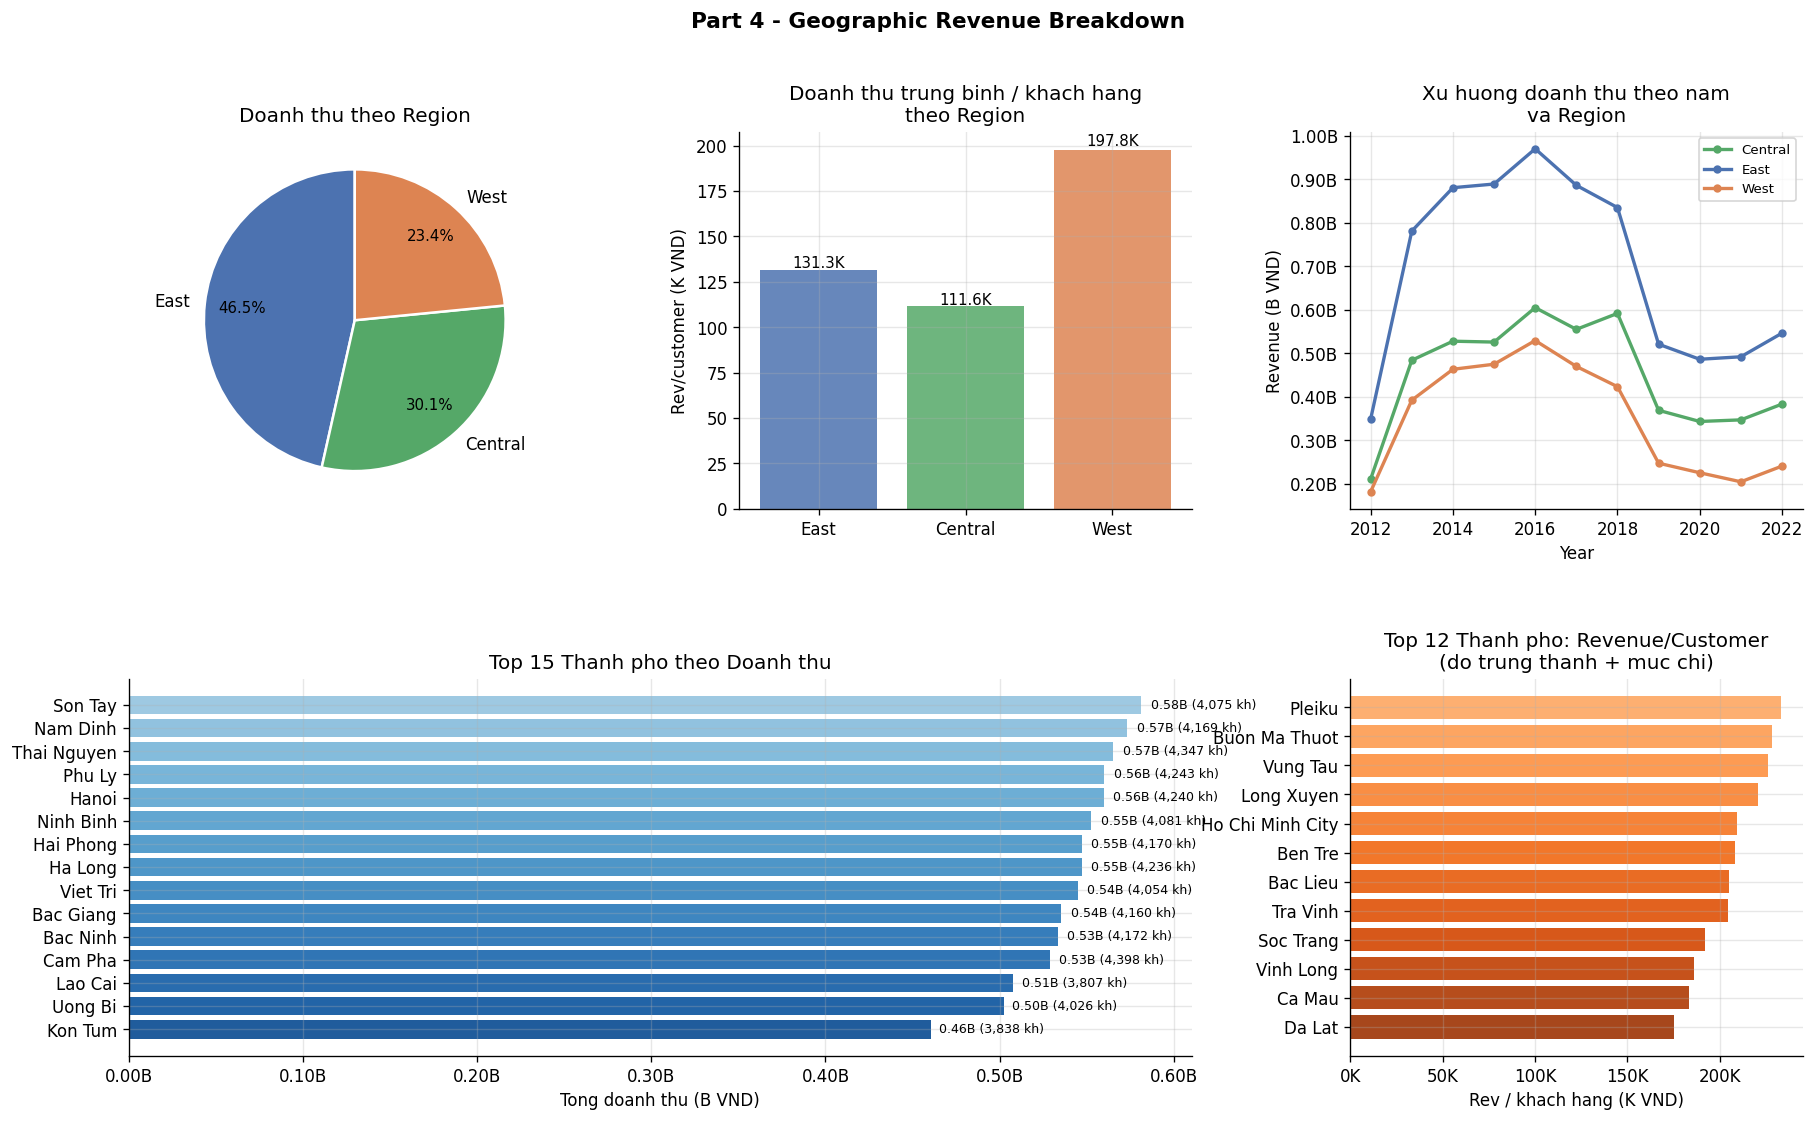

In [9]:
fig = plt.figure(figsize=(18, 10))
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

REG_COLORS = {'East':'#4C72B0','West':'#DD8452','Central':'#55A868','North':'#C44E52',
              'South':'#9467BD'}
reg_colors_ = [REG_COLORS.get(r,'#aaa') for r in region_rev['region']]

# ── A: Revenue by Region pie ──────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
wedges, texts, autos = ax0.pie(
    region_rev['total_rev'], labels=region_rev['region'],
    autopct='%1.1f%%', colors=reg_colors_, startangle=90,
    pctdistance=0.75, wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autos: at.set_fontsize(9)
ax0.set_title('Doanh thu theo Region')

# ── B: Revenue per customer by region ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
bars = ax1.bar(region_rev['region'], region_rev['rev_per_cust']/1e3,
               color=reg_colors_, alpha=0.85)
ax1.set_ylabel('Rev/customer (K VND)')
ax1.set_title('Doanh thu trung binh / khach hang\ntheo Region')
for bar, val in zip(bars, region_rev['rev_per_cust']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
             f'{val/1e3:.1f}K', ha='center', fontsize=9)

# ── C: Annual Revenue trend by region ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
for reg in region_annual.columns:
    ax2.plot(region_annual.index, region_annual[reg]/1e9,
             marker='o', ms=4, lw=2, label=reg,
             color=REG_COLORS.get(reg,'#aaa'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.2f}B'))
ax2.set_xlabel('Year'); ax2.set_ylabel('Revenue (B VND)')
ax2.set_title('Xu huong doanh thu theo nam\nva Region')
ax2.legend(fontsize=8)

# ── D: Top 15 cities ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
top15 = city_rev.head(15)
palette = plt.cm.Blues(np.linspace(0.4, 0.9, 15))[::-1]
bars2 = ax3.barh(top15['city'][::-1], top15['total_rev'][::-1]/1e9, color=palette, alpha=0.9)
ax3.set_xlabel('Tong doanh thu (B VND)')
ax3.set_title('Top 15 Thanh pho theo Doanh thu')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.2f}B'))
for bar, (_, row) in zip(bars2, top15[::-1].iterrows()):
    ax3.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
             f'{row["total_rev"]/1e9:.2f}B ({row["n_customers"]:,} kh)',
             va='center', fontsize=7.5)

# ── E: Rev/customer by city (top 15) ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
top15_rpc = city_rev.sort_values('rev_per_cust', ascending=False).head(12)
palette2 = plt.cm.Oranges(np.linspace(0.4, 0.9, 12))[::-1]
ax4.barh(top15_rpc['city'][::-1], top15_rpc['rev_per_cust'][::-1]/1e3,
         color=palette2, alpha=0.9)
ax4.set_xlabel('Rev / khach hang (K VND)')
ax4.set_title('Top 12 Thanh pho: Revenue/Customer\n(do trung thanh + muc chi)')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}K'))

plt.suptitle('Part 4 - Geographic Revenue Breakdown', fontsize=13, fontweight='bold')
plt.savefig('fig_cust_p4_geo.png', bbox_inches='tight')
plt.show()


## Summary

In [10]:
print('=' * 65)
print('CUSTOMER & GROWTH SUMMARY')
print('=' * 65)
print()
print('=== RFM Segmentation ===')
for _, row in seg_summary.iterrows():
    print(f'  {row["segment"]:18s}: {row["n_customers"]:>7,} kh  '
          f'({row["cust_share_pct"]:.1f}% kh / {row["rev_share_pct"]:.1f}% rev)  '
          f'avg_freq={row["avg_freq"]:.1f}  avg_mon={row["avg_monetary"]/1e3:.0f}K VND')
print()
print('=== Cohort Retention (First-Order) ===')
avg_ret = retention_matrix.mean(axis=0)
for offset, val in avg_ret.items():
    print(f'  Year+{offset}: {val:.1f}% trung binh con mua hang')
print()
print('=== Channel Quality (xep theo quality_score) ===')
for _, row in channel_summary.iterrows():
    print(f'  {row["acquisition_channel"]:20s}: score={row["quality_score"]:.1f}  '
          f'LTV={row["avg_ltv"]/1e3:.0f}K  one_time={row["pct_one_time"]:.1f}%  '
          f'n={row["n_customers"]:,}')
print()
print('=== Geographic Breakdown ===')
for _, row in region_rev.iterrows():
    print(f'  {row["region"]:10s}: {row["rev_share_pct"]:.1f}% rev  '
          f'{row["n_customers"]:,} kh  rev/kh={row["rev_per_cust"]/1e3:.0f}K')
print(f'  Top city: {city_rev.iloc[0]["city"]}  ({city_rev.iloc[0]["total_rev"]/1e9:.2f}B VND)')


CUSTOMER & GROWTH SUMMARY

=== RFM Segmentation ===
  Champions         :  23,446 kh  (26.0% kh / 63.9% rev)  avg_freq=17.2  avg_mon=448K VND
  Loyalists         :  19,718 kh  (21.8% kh / 21.2% rev)  avg_freq=7.0  avg_mon=177K VND
  Potential         :  16,968 kh  (18.8% kh / 6.6% rev)  avg_freq=2.6  avg_mon=64K VND
  New / Promising   :   4,869 kh  (5.4% kh / 1.4% rev)  avg_freq=1.6  avg_mon=47K VND
  Hibernating       :   1,236 kh  (1.4% kh / 0.1% rev)  avg_freq=1.0  avg_mon=11K VND
  At Risk           :   3,247 kh  (3.6% kh / 4.0% rev)  avg_freq=8.4  avg_mon=200K VND
  Lost              :  20,762 kh  (23.0% kh / 2.9% rev)  avg_freq=1.2  avg_mon=23K VND

=== Cohort Retention (First-Order) ===
  Year+0: 100.0% trung binh con mua hang
  Year+1: 24.6% trung binh con mua hang
  Year+2: 26.1% trung binh con mua hang
  Year+3: 26.7% trung binh con mua hang
  Year+4: 27.7% trung binh con mua hang
  Year+5: 27.9% trung binh con mua hang
  Year+6: 28.5% trung binh con mua hang
  Year+7: 28.2%